# Language Processing and LLMs

This week we're going to do a high-level flythrough of LLMs and textual
generative AI. Just as image-based ML was unlocked with the creation of
convolutional layers, text-based ML was unlocked with the more recent
creation of transformers in a paper significant enough [to have its own
Wikipedia page](https://en.wikipedia.org/wiki/Attention_Is_All_You_Need).

In this first lecture, we're going to walk through the creation of feature
extractors for language, which are the backbone of networks that do all sort
of interesting things with language.

## The Decomposition of Language via Tokenization

The first stage in the Transformer pipeline is **Tokenization**, the process
of partitioning raw text into discrete numerical units. Modern Transformers
employ **sub-word tokenization**, where the language is broken down into a
discrete set of portions of words that have meaning. This method decomposes
words into the smallest sequences of characters that appear frequently in a
training corpus. For example, the word **"transformed"** may be broken into
three tokens: `trans` (a prefix indicating movement or change), `form` (the
root), and `ed` (a suffix denoting past tense). This structural breakdown
allows the model to handle rare or unseen words by interpreting their
constituent parts, ensuring it can derive meaning from a word like
"translocate" if it has previously encountered its components in other
contexts.

Modern multilingual LLMs typically have a couple hundred thousand tokens in their dictionary.

Tokens must be embedded - after all, neural nets can't work on words, they
need to work on numbers, so we need to create a vector to represent each
token. Initially, each token in a vocabulary of size $V$ tokens is represented by an integer from $0 - (V-1)$. This is then changed into a one-hot vector of length $V$, where only the element at the appropriate dimension is a 1.

This is technically an embedding, but we'd prefer one that is meaningful such that the geometry of embeddings
is semantically meaningful (for example, perhaps the
embeddings of "hot" and "warm" should be close together, because they mean
similar things, while a word like "astronomy" should be quite distant, because
its meaning and use is quite different).

Naturally, we learn to transform our one-hot embeddings to these semantic embeddings through self-supervised learning, so we
can make use of the massive amount of unlabeled text available online. We task
the embedding model with a proxy problem, such as **Masked Language
Modeling**. In this scenario, the model is given a head that can classify over
all tokens and is given a sentence like "The chef cooked a delicious
**[MASK]**" and must predict the hidden token. To succeed, the model must
learn the statistical relationships between "chef," "cooked," and potential
targets like "meal" or "steak." Through backpropagation, the model adjusts the
token vectors until it can perform this task, and the geometric distances
between word embeddings accurately reflect these linguistic patterns.

Once learned, the embeddings for the tokens are precalculated and stored in a matrix.

![](embeddings.png)

## Contextual Refinement via Self-Attention

While embeddings provide a general definition of tokens, they don't solve the
whole problem. For example, consider the definition of "crane." Do you mean
the bird, or the construction equipment? The answer depends upon the context
of the sentence it is used in. The **Self-Attention** mechanism provides the
specific context required for this understanding. Self-attention allows each token in a sequence to "communicate" with every other token to resolve ambiguity. For example, in the sentence "The **crane** flew over the construction site," the mechanism calculates a high attention score between **"crane"** and **"flew,"** signaling that the word refers to a bird. If the sentence were "The **crane** lifted the steel beam," the attention would shift to "lifted" and "steel," updating the representation of "crane" to reflect a piece of machinery.

## The Transformer Block and Hierarchical Feature Extraction

A **Transformer Block** is the fundamental unit of the architecture, housing the multi-head self-attention mechanism and a position-wise feed-forward network. By stacking these blocks, the model functions as a hierarchical feature extractor, analogous to the layers of a **Convolutional Neural Network (CNN)**. In a CNN, early layers detect simple edges and textures while later layers identify complex objects like faces. Similarly, the initial blocks of a Transformer extract simple syntax and local word relationships. As data progresses through deeper layers, the model extracts increasingly abstract features, such as logical intent, thematic consistency, and global context. This stacking transforms raw token embeddings into sophisticated representations of human language.

## Demo of attention weights

Here we take a pretrained language backbone called [BERT](https://en.wikipedia.org/wiki/BERT_(language_model)), and feed in some sentences to look at how the system has learned to identify which other tokens in the sentence are relevant to given words. This first part is all just setup...

In [1]:
import torch
from transformers import BertTokenizer, BertModel
import matplotlib.pyplot as plt
import seaborn as sns

import os
import httpx
from huggingface_hub import constants

# 1. Standard environment bypasses
os.environ['HF_HUB_DISABLE_SSL_VERIFY'] = '1'
os.environ['CURL_CA_BUNDLE'] = ''

# 2. Force httpx to ignore SSL structural errors (Missing Authority Key Identifier)
# We wrap the original client to ensure verify=False is always passed.
original_client = httpx.Client

class UnverifiedClient(original_client):
    def __init__(self, *args, **kwargs):
        kwargs['verify'] = False
        super().__init__(*args, **kwargs)

httpx.Client = UnverifiedClient

# 3. Suppress warnings
import warnings
from urllib3.exceptions import InsecureRequestWarning
import requests
requests.packages.urllib3.disable_warnings(category=InsecureRequestWarning)
warnings.filterwarnings('ignore')

In [2]:
# Load a pre-trained model and tokenizer
# We output_attentions=True to access the internal weights
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased', output_attentions=True)

def visualize_word_attention(sentence, target_word, layer=-1):
    """
    Extracts and visualizes the attention weights for a specific word in a sentence.
    """
    # Tokenize input text
    inputs = tokenizer(sentence, return_tensors="pt")
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    
    # Run the model to extract attention layers
    with torch.no_grad():
        outputs = model(**inputs)
        
    # Extract attention from Layer 5 (index 5) instead of the final layer (-1)
    # outputs.attentions shape: (num_layers, batch_size, num_heads, sequence_length, sequence_length)
    target_layer_attention = outputs.attentions[layer][0].mean(dim=0).numpy()
    
    # Locate the index of the target word
    try:
        target_idx = tokens.index(target_word)
    except ValueError:
        print(f"Target word '{target_word}' not found in the tokenized sequence: {tokens}")
        return
        
    # Isolate the attention weights for the target word
    word_attention_weights = target_layer_attention[target_idx]
    
    # Visualize using a heatmap
    plt.figure(figsize=(12, 2))
    sns.heatmap(
        [word_attention_weights], 
        xticklabels=tokens, 
        yticklabels=[target_word], 
        cmap="Blues", 
        annot=True, 
        fmt=".2f",
        cbar=False
    )
    plt.title(f"Self-Attention Weights for '{target_word}'")
    plt.xlabel("Attended Tokens")
    plt.show()



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### OK!

OK, so we have it all set up now. Early layers generally tie tokens back together into whole words, or connect tokens with the ones next to them. Middle layers recognize which words deal with which words, and later layers contain more abstract ideas of sentence meaning and intent.

We start by looking at the sentence "The fat cat sat in the bright sun", and look at in the 5th layer, what other tokens are connected to "cat", "sun", and "sat"?

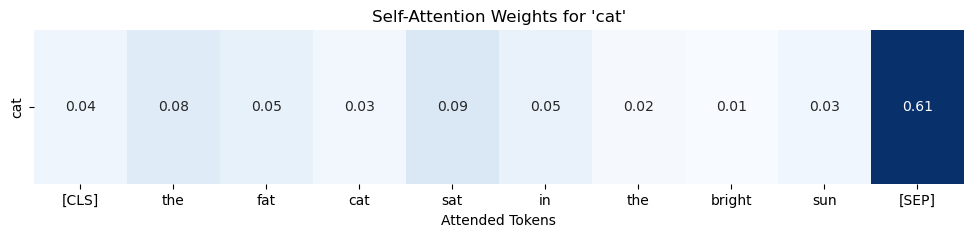

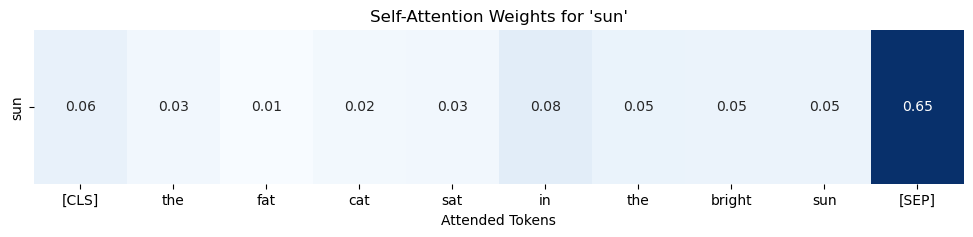

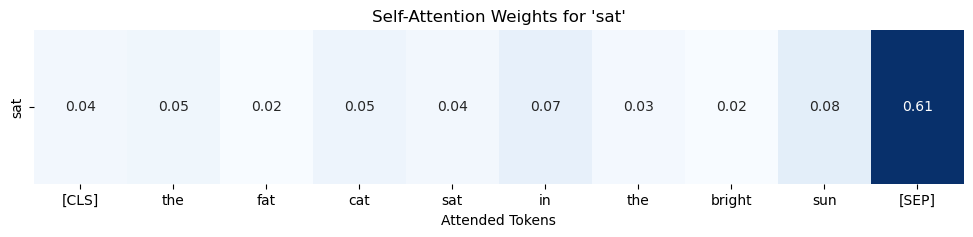

In [3]:
sentence = "the fat cat sat in the bright sun"
visualize_word_attention(sentence, "cat", layer=5)

visualize_word_attention(sentence, "sun", layer=5)

visualize_word_attention(sentence, "sat", layer=5)

We can see that "cat" is attended to "the", "fat", and "sat", which are all words that relate directly to the cat, and less to any of the words about the sun.

"Sun" is attended to by "in", "the", and "bright".

"Sat" is attended to by "in", "cat", and "sun".

That all makes sense!

Now let's look at an example that shows why language can be hard. "The cat sat in the sun. It was fat." and "The cat sat in the sun. It was bright." are grammatically identical, but yet "It" is ambiguous. A good language model has to understand what "It" refers to from the context around it.

By looking at the 9th layer (a little deeper...), we can see that in the first snippet, "It" is most heavily attended to by "cat" and "fat." In the second, it's most heavily attended to by "bright" and "sun." It's figured it out!

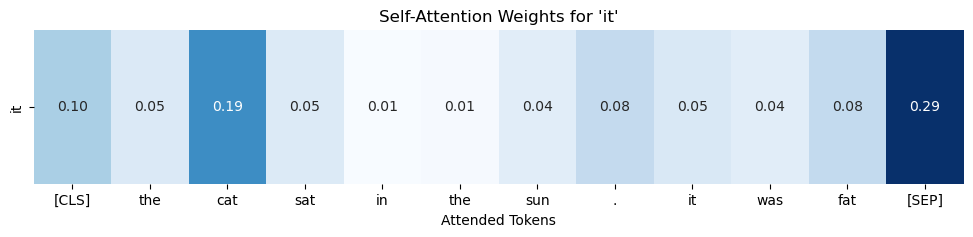

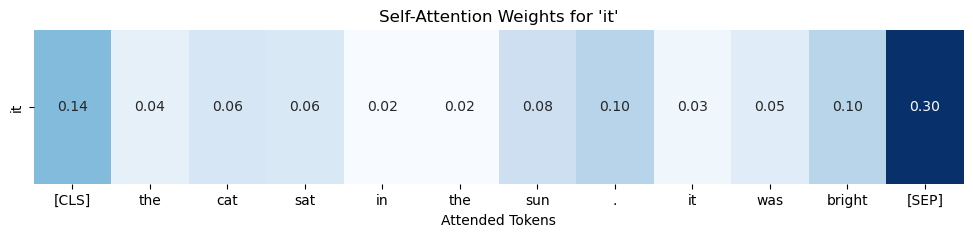

In [4]:
sentence_1 = "the cat sat in the sun. it was fat"
visualize_word_attention(sentence_1, "it", layer=9)

sentence_2 = "the cat sat in the sun. it was bright"
visualize_word_attention(sentence_2, "it", layer=9)

## The final text-wide embedding

The final output of something like BERT is an embedding of a full block of text, which includes features indicating the semantic meaning of the block of text. Ideally, this embedding would be the same regardless of the language it was originally written in, or the specific word choice of the author, etc. It makes an excellent backbone for a large variety of language-based tasks such as translation, or text generation.

"Semantic" means an understanding of the meaning, rather than just something statistical and computational. Its definition falls into the same fuzzy areas as "intelligence" and "understanding," which come up often in philosophical/mystical discussions of AI.

![](https://www.smbc-comics.com/comics/1773639229-20260317.png)

*(Cartoon from the excellent [Saturday Morning Breakfast Cereal](https://www.smbc-comics.com/index.php))*